## Conversion of xlsx timeseries of discharge flow rate to MOHID .dat format.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

### Read file

In [2]:
filename = Path('../../data/discharge/Caudales_PSJ_2025.xlsx')
output_folder = filename.parent

df = pd.read_excel(
    filename,
    sheet_name='Septiembre',
    usecols=['Fecha', 'Caudal salida general (l/h)']
)

### Conversions and building names

In [3]:
df['datetime'] = pd.to_datetime(df['Fecha']) - pd.Timedelta(hours=1) # convert to wintertime
df['flow (m3/s)'] = df['Caudal salida general (l/h)'] / (3600000)  # convert unit
df = df.dropna()

# Build the seconds column relative to the first timestamp
t0 = df['datetime'].iloc[0]
df['seconds'] = (df['datetime'] - t0).dt.total_seconds().astype(int)

# build fileout name
start = df['datetime'].iloc[0]
end = df['datetime'].iloc[-1]
fileout = output_folder / f"discharge_{start.year}_{start.month}_{start.day}_{end.year}_{end.month}_{end.day}.dat"
 
# build the header with serie intitial data from datetime
initial = f"{t0.year}. {t0.month:>2}. {t0.day:>2}. {t0.hour}. {t0.minute}. {t0.second}."

df.head()

,Fecha,Caudal salida general (l/h),datetime,flow (m3/s),seconds
0,2025-09-01 01:00:00,10665.990021,2025-09-01 00:00:00,0.002963,0
1,2025-09-01 02:15:00,5620.894484,2025-09-01 01:15:00,0.001561,4500
2,2025-09-01 03:30:00,10917.330831,2025-09-01 02:30:00,0.003033,9000
3,2025-09-01 04:45:00,15231.253101,2025-09-01 03:45:00,0.004231,13500
4,2025-09-01 06:00:00,5620.894484,2025-09-01 05:00:00,0.001561,18000


### Write file

In [4]:
with open(fileout, 'w') as f:
    f.write("TIME_UNITS                : SECONDS\n")
    f.write(f"SERIE_INITIAL_DATA        : {initial}\n")
    f.write("\n")
    f.write("SECONDS                   flow (m3/s)\n")
    f.write("<BeginTimeSerie>\n")
    for _, row in df.iterrows():
        f.write(f"{row['seconds']}                           "
                f"{row['flow (m3/s)']:.10g}\n")
    f.write("<EndTimeSerie>\n")

In [5]:
df

,Fecha,Caudal salida general (l/h),datetime,flow (m3/s),seconds
0,2025-09-01 01:00:00,10665.990021,2025-09-01 00:00:00,0.002963,0
1,2025-09-01 02:15:00,5620.894484,2025-09-01 01:15:00,0.001561,4500
2,2025-09-01 03:30:00,10917.330831,2025-09-01 02:30:00,0.003033,9000
3,2025-09-01 04:45:00,15231.253101,2025-09-01 03:45:00,0.004231,13500
4,2025-09-01 06:00:00,5620.894484,2025-09-01 05:00:00,0.001561,18000
...,...,...,...,...,...
570,2025-09-30 18:45:00,109666.850263,2025-09-30 17:45:00,0.030463,2569500
571,2025-09-30 20:00:00,109666.850263,2025-09-30 19:00:00,0.030463,2574000
572,2025-09-30 21:15:00,109666.850263,2025-09-30 20:15:00,0.030463,2578500
573,2025-09-30 22:30:00,109666.850263,2025-09-30 21:30:00,0.030463,2583000


### Visualize

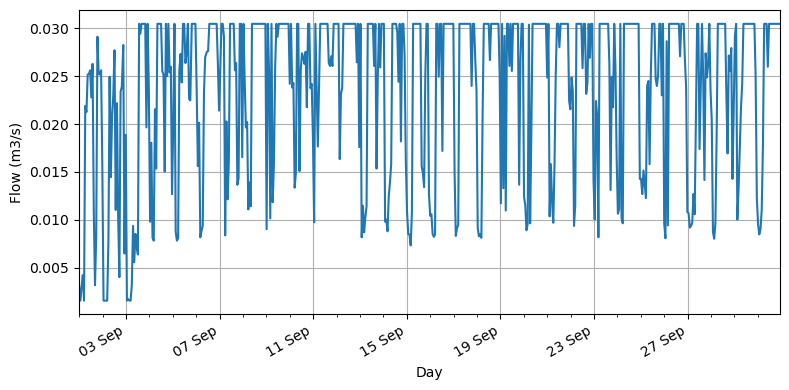

mean: 0.02356820459721158 
 max: 0.030463013962005032 
 min: 0.0015613595788509956 



In [6]:
df_flow = pd.DataFrame({
    "date": df['datetime'],
    "flow": df['flow (m3/s)']
})


fig, ax = plt.subplots(figsize=(8, 4))


ax.plot(
    df_flow['date'],
    df_flow['flow']
)

ax.set_ylabel("Flow (m3/s)")
ax.set_xlabel("Day")
ax.grid(True)

# X-axis formatting
ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_xlim(
    df_flow['date'].min(),
    df_flow['date'].max()
)
fig.autofmt_xdate()
plt.tight_layout()

plt.show()

print(
    'mean:', df_flow['flow'].mean(), '\n',
    'max:', df_flow['flow'].max(), '\n',
    'min:', df_flow['flow'].min(), '\n'
)